In [1]:
from manim import *
# from classes.electrodynamics_classes import *
import jupyter_capture_output
from numpy import linalg as npl

video_scene = " -v WARNING --disable_caching ampere_Scene"
image_scene = f" -v WARNING --disable_caching -r {2*427},{2*240}  -s ampere_Scene"

Jupyter Capture Output v0.0.11


In [2]:
# main color of the animation (opposite of the background color)
# main_color = BLACK
# inverted_main_color = WHITE
# red_color = PURE_RED
# blue_color = PURE_BLUE
# grey_color = DARK_GREY

main_color = WHITE
inverted_main_color = BLACK
red_color = RED
blue_color = BLUE
grey_color = GREY

In [ ]:
class Conductor(Mobject):
	def __init__(self, I, center = np.array([-4, -0.5, 0]), direction = np.array([3, 0, 1]), **kwargs):
		super().__init__(**kwargs)

		self.I = I
		self.center = center
		self.direction = direction

		# conductor
		conductor_cylinder = Cylinder(radius = 0.2, height = 10, resolution = (12, 12), direction = self.direction, checkerboard_colors = (WHITE, LIGHT_GRAY), fill_color = GREY).move_to(center)
		self.add(conductor_cylinder)


		# coordinate system
		self.e_x = UP
		self.e_z = direction / npl.norm(direction)
		self.e_y = np.cross(self.e_z, self.e_x)

		x_arrow = Arrow3D(start = self.center, end = self.center + self.e_x, color = RED)
		y_arrow = Arrow3D(start = self.center, end = self.center + self.e_y, color = BLUE)
		z_arrow = Arrow3D(start = self.center, end = self.center + self.e_z, color = BLACK)
        # self.add(x_arrow, y_arrow, z_arrow)

    
    # method to return points in 3D space for given conductor coordinates (lol too easy)
	def cc2p(self, x, y, z):
		return self.center + x*self.e_x + y*self.e_y + z*self.e_z


    # method to get field function for a given z
    # def get_field_function(self, z_layer):
	def get_field_function(self, x, y, z):
		r_squared = x**2 + y**2 + 0.0001
		normalization = 10
		return (-y/normalization/r_squared*self.e_x + x/normalization/r_squared*self.e_y)
		# return (-y/normalization*RIGHT + x/normalization*UP)
		# return self.e_z
		# return field_function


    # method to get the field for a given z value
	def get_field(self, z = 0, r_range = 2):
		n_vectors = 7
		d_vector = 2*r_range / (n_vectors-1)
		vector_group = VGroup()
		for i_x in range(n_vectors):
			for i_y in range(n_vectors+1):
				x = -r_range + d_vector*i_x
				y = -r_range + d_vector*i_y

				vector_start_pos = self.cc2p(x, y, z)
				vector_end_pos = vector_start_pos + self.I*self.get_field_function(x, y, z)
				vector = Line(start = vector_start_pos, end = vector_end_pos, color = BLUE, stroke_width = 2).add_tip(tip_length = 0.1, tip_width = 0.1)
				vector_group.add(vector)
		return vector_group
    

	# method to return the function for a circular ampere loop
	def get_ampere_loop_function(self, z = 0, radius = 1):
		def ampere_loop_function(phi):
			x = radius * np.cos(phi)
			y = radius * np.sin(phi)
			return np.array([x, y, z])
		return ampere_loop_function
      
	
	# take a parametric function takin one variable mapping to internal coordinates and return it in scene coordinates (possibly obsolete)
	def scenanalize_function(self, function):
		def function_to_scene(phi):
			internal_coordinates = function(phi)
			return self.cc2p(*internal_coordinates)
		return function_to_scene

        
	# method to return a given ampere loop as parametric function
	def get_ampere_loop(self, ampere_loop_function):
		ampere_loop_function_scenalized = self.scenanalize_function(ampere_loop_function)
		parametric_ampere_loop = ParametricFunction(ampere_loop_function_scenalized, color = main_color, stroke_opacity = 0.5, stroke_width = 4, t_range = np.array([0, 2*PI, 0.01]))
		return parametric_ampere_loop
        
    

	# method to return an individual vector
	def get_ampere_vector(self, x, y, z):
		vector_start_pos = self.cc2p(x, y, z)
		vector_end_pos = vector_start_pos + self.I*self.get_field_function(x, y, z)
		vector = Line(start = vector_start_pos, end = vector_end_pos, color = WHITE, stroke_width = 2).add_tip(tip_length = 0.1, tip_width = 0.1)
		return vector
      

	# method to return the length of the B-field path projection
	def get_ampere_vector_proj_length_function(self, ampere_loop_function):
		def get_ampere_vector_proj_lenght(phi):
			internal_coordinates = ampere_loop_function(phi)
			vector_length = np.sum((self.I*self.get_field_function(*internal_coordinates))**2)
			return vector_length
		return get_ampere_vector_proj_lenght
      
      
	# method to sum of all length of the B-field path projections up to a certain angle phi
	def get_ampere_vector_proj_length_integrated_function(self, ampere_loop_function):
		ampere_vector_proj_length_function = self.get_ampere_vector_proj_length_function(ampere_loop_function)
		def get_ampere_vector_proj_length_integrated(phi):
			dt = 0.025
			phi_run = 0
			sum = 0
			while (phi_run < phi):
				vector_length = ampere_vector_proj_length_function(phi_run)
				sum += vector_length*dt
				phi_run += dt
			return sum / 5
		return get_ampere_vector_proj_length_integrated


	# method to return the projection of an individual vector on the ampere loop
	def get_ampere_vector_proj(self, x, y, z):
		return


    # return ArrowVectorField(self.get_field_function, x_range = [-r_range, r_range], y_range = [-r_range, r_range], min_color_scheme_value=0, max_color_scheme_value=5).move_to(self.cc2p(0, 0, z)
    


class AmpereLegend(Mobject):
    def __init__(self, center = np.array([0, 0, 0]), height = 6, width = 5, opacity = 0.75, **kwargs):
        super().__init__(**kwargs)

        # legend background
        legend_bg = Rectangle(height = height, width = width, color = inverted_main_color, stroke_color = inverted_main_color, stroke_opacity = opacity, fill_opacity = opacity).move_to(center)
        legend_bg.z_index = 0.5
        self.add(legend_bg)

        # mathematical description of amperes law
        legend_title = MathTex(r"\mu_0I=\oint_{\partial A}\Vec{B}\cdot d\Vec{s}", font_size = 36, color = main_color).next_to(legend_bg, UP).shift(1.5*DOWN)
        for i in range(len(legend_title[0])):
            legend_title[0][i].z_index = 4
        self.add(legend_title)

        # coordinate system for the integration
        x_range = [0, 2*PI + PI / 4, PI / 2]
        y_range = [-0.45, 0.45, 0.5]
        x_length = width / 1.35
        y_length = height / 3.75

        x_dict = dict(zip([PI, 2*PI], [r"$\pi$", r"$2\pi$"]))
        self.ax = Axes(x_range = x_range, y_range = y_range, x_length = x_length, y_length = y_length, 
            axis_config = {"stroke_width": 1, "stroke_opacity": 1, "tip_width": 0.125, "tip_height": 0.125, "stroke_color": main_color}).next_to(legend_title, 1.5*DOWN).add_coordinates(x_dict).shift(0.25*RIGHT + 0.15*DOWN)
        ax_ylabel = self.ax.get_y_axis_label(MathTex(r"\Vec{B}\cdot\Vec{s}", font_size = 24, color = main_color)).shift(LEFT + 0.25*DOWN)
        for i in range(len(ax_ylabel[0])):
            ax_ylabel[0][i].z_index = 4
        self.ax.x_axis.tip.z_index = 4
        self.ax.y_axis.tip.z_index = 4
        for tick in self.ax.x_axis.ticks:
            tick.z_index = 4
        for tick in self.ax.y_axis.ticks:
            tick.z_index = 4
        for axis in self.ax:
            axis.z_index = 4
        self.ax.x_axis.labels.set_color(color = main_color)
        for label in self.ax.x_axis.labels:
            for i in range(len(label[0])):
                label[0][i].z_index = 4
        self.add(self.ax, ax_ylabel)

        self.ax_int = Axes(x_range = x_range, y_range = y_range, x_length = x_length, y_length = y_length, 
            axis_config = {"stroke_width": 1, "stroke_opacity": 1, "tip_width": 0.125, "tip_height": 0.125, "stroke_color": main_color}).next_to(legend_title, 1.5*DOWN).add_coordinates(x_dict).shift(0.25*RIGHT + 2.45*DOWN)
        ax_int_ylabel = self.ax_int.get_y_axis_label(MathTex(r"\oint_{\partial A}\Vec{B}\cdot d\Vec{s}", font_size = 24, color = red_color)).shift(1.1*LEFT + 0.125*DOWN)
        for i in range(len(ax_int_ylabel[0])):
            ax_int_ylabel[0][i].z_index = 4
        self.ax_int.x_axis.tip.z_index = 4
        self.ax_int.y_axis.tip.z_index = 4
        for tick in self.ax_int.x_axis.ticks:
            tick.z_index = 4
        for tick in self.ax_int.y_axis.ticks:
            tick.z_index = 4
        for axis in self.ax_int:
            axis.z_index = 4
        self.ax_int.x_axis.set_color(color = main_color)
        for label in self.ax_int.x_axis.labels:
            for i in range(len(label[0])):
                label[0][i].z_index = 4
        self.add(self.ax_int, ax_int_ylabel)
        

    def get_plot(self, function, phi):
        plot_function = self.ax.plot(function, color = main_color, x_range = [-0.001, phi])
        plot_function.z_index = 4
        plot_function_area = self.ax.get_area(plot_function, x_range = [-0.001, phi], color = main_color, opacity = 0.5)
        plot_function_area.z_index = 4
        return VGroup(plot_function, plot_function_area)
    

    def get_integrated_plot(self, function, phi):
        plot_function = self.ax_int.plot(function, color = red_color, x_range = [-0.001, phi])
        plot_function.z_index = 4
        plot_function_area = self.ax_int.get_area(plot_function, x_range = [-0.001, phi], color = red_color, opacity = 0.5)
        plot_function_area.z_index = 4
        return VGroup(plot_function, plot_function_area)

Manim Community v0.18.1

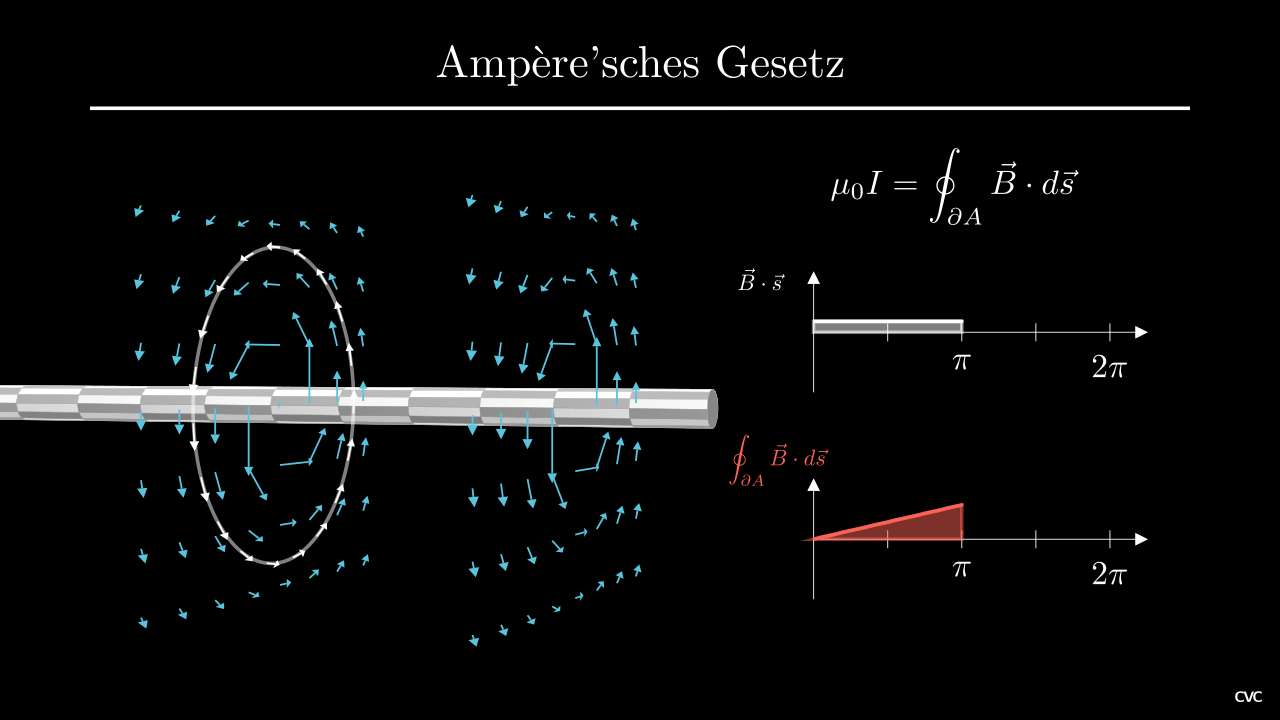

In [40]:
%%manim -qm --fps 60 $video_scene


class ampere_Scene(ThreeDScene):
	def construct(self):
		CVC = Text('CVC', font_size = 12, weight = BOLD, color = main_color, font = 'Latin Modern Sans').align_on_border(RIGHT + DOWN, buff = 0.2)
		self.add(CVC)

		# headline
		headline = Title(r"Ampère'sches Gesetz", font_size = 48, color = main_color).align_on_border(UP + LEFT, buff = 0.5).shift(0.5 * RIGHT)
		self.add(headline)

		# conductor
		conductor = Conductor(I = 5)
		conductor_field_minus = conductor.get_field(z = -1.5)
		conductor_field = conductor.get_field(z = 0)
		conductor_field_plus = conductor.get_field(z = 3.5)
		self.add(conductor, conductor_field, conductor_field_plus)

		# ampere loop function


		# ampere loop
		ampere_loop_function = conductor.get_ampere_loop_function(radius = 1.75)
		ampere_loop = conductor.get_ampere_loop(ampere_loop_function)
		self.add(ampere_loop)

		# ampere loop vectors
		ampere_loop_vector_group = VGroup()
		for phi in np.linspace(0, 2*PI, 20):
			vector_coords = ampere_loop_function(phi)
			ampere_vector_phi = conductor.get_ampere_vector(*vector_coords)
			ampere_loop_vector_group.add(ampere_vector_phi)


		# legend
		legend = AmpereLegend(center = np.array([3.5, +0.25, 0]), height = 5, width = 5)
		self.add(legend)

		legend_func = conductor.get_ampere_vector_proj_length_function(ampere_loop_function)
		legend_integrated_func = conductor.get_ampere_vector_proj_length_integrated_function(ampere_loop_function)
		legend_plot = legend.get_plot(legend_func, PI)
		legend_plot_integrated = legend.get_integrated_plot(legend_integrated_func, PI)
		self.add(legend_plot, legend_plot_integrated)


		self.add(ampere_loop_vector_group)


		def plot_updater(plot):
			phi = phi_tracker.get_value()
			plot_func = plot.func
			plot_getter = plot.plot_getter
			plot.become(plot_getter(function = plot_func, phi = phi))


		def vector_updater(vector_group):
			phi = phi_tracker.get_value()
			index_from_phi = min(int((phi * 20) / (2*PI)), 19)
			vector_group[index_from_phi].set_color(red_color)

		# animation
		# self.wait(1.5)
		# self.play(FadeIn(ampere_loop_vector_group), run_time = 3)
		# self.wait(3)


		# phi_tracker = ValueTracker(0)
        # self.play(phi_tracker.animate.set_value(2*PI), rate_func= linear, run_time = 10)    
        # self.wait(5)